# 14 — Gate 4 results: the decision architecture (OG-04 style; zero solves)

**The reframe this analysis earns:** the certified optimal map is real but nearly meaningless
as a summary — a plan sharing almost no discretionary land with it performs within 5% as
well. So the useful question is not *"what is the best 30%?"* but three separable decisions:

1. **What does every good plan need?** → the ensemble's frequent tier (ratify, act first)
2. **Where do values decide?** → the conditional tier (the real values conversation)
3. **Where are we free?** → the exchangeable pool (outside-model criteria may govern)

…plus the one exception (carbon's securable strongholds) and the standing caveats. Everything
below reads Gate-3/4 artifacts; runtime ≈ 2–4 min; kernel `y2y-geo`.

In [65]:
# ---- bootstrap + one streaming load of the ensemble ----------------------------------------
import importlib, json, pathlib, sys

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy import ndimage

_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.py").exists()]
assert _cands, "config.py not found above the notebook"
ROOT = _cands[0]
sys.path.insert(0, str(ROOT))
import config, leverage_core as lc, ensemble_core as ec
for _m in (config, lc, ec):
    importlib.reload(_m)

SPEC = ROOT / "analyses" / "y2y" / "spec"
RUNS = ROOT / "analyses" / "y2y" / "runs"
FIG = ROOT / "analyses" / "y2y" / "figures"
MAN = pd.read_csv(SPEC / "manifest.csv")
FORMS = list(MAN.formulation_id)
pu = lc.pu_mask()
with rasterio.open(config.HANDOFF_DIR / "mask_protected_areas.tif") as src:
    locked2d = (src.read(1) == 1) & pu
locked = locked2d[pu]
disc = ~locked

F_FORM, ANCHORS, META = {}, {}, {}
for c in FORMS:
    META[c] = json.loads((RUNS / c / "formulation_meta.json").read_text())
    A = ec.read_selections(RUNS / c / "anchor.tif", pu)[0]
    M = ec.read_selections(RUNS / c / "mga_g05.tif", pu)
    F_FORM[c] = np.vstack([A[None, :], M]).mean(axis=0).astype(np.float32)
    ANCHORS[c] = A
    del M
Fh = np.mean([F_FORM[c] for c in FORMS], axis=0)
halo = [pe.withStroke(linewidth=2.5, foreground="white")]

def to_grid(v):
    G = np.full(pu.shape, np.nan, dtype=np.float32)
    G[pu] = v
    return G
print(f"loaded {len(FORMS)} formulations | PU {int(pu.sum()):,} | discretionary {int(disc.sum()):,}")

loaded 14 formulations | PU 1,272,914 | discretionary 1,081,885


## Context — the six scenarios: what feeds them, and how

One column per value scenario; rows are the input layers grouped by PROACT block. Every
scenario is a complete (weight, target) recipe over the SAME stack — no layers are added or
removed. EFGs and intactness are handled identically everywhere (bottom rows) and sit outside
the influence budgeting, disclosed. Each scenario then solves on both climate layers (ssp245
weights re-derived to hold intended influence constant) + 2 crossed carbon-regime cells =
the 14 formulations.

                                                      S0 Balanced      S1 Core-habitat      S2 Connectivity      S3 Biodiversity            S4 Carbon        S5 Intactness
core habitat · macrorefugia (AdaptWest 1/v)                w 1.46               w 3.09               w 0.96               w 0.78               w 1.23               w 1.46
connectivity · connectivity (Pither/O'Brien)               w 0.67               w 0.47               w 1.32               w 0.36               w 0.56               w 0.67
connectivity · climate corridors (Carroll)                 w 1.17               w 0.83               w 2.30               w 0.63               w 0.99               w 1.17
biodiversity · AOH richness — birds                        w 1.33               w 0.94               w 0.87               w 2.13               w 1.12               w 1.33
biodiversity · AOH richness — mammals                      w 1.71               w 1.20               w 1.12               w 2.74               w 

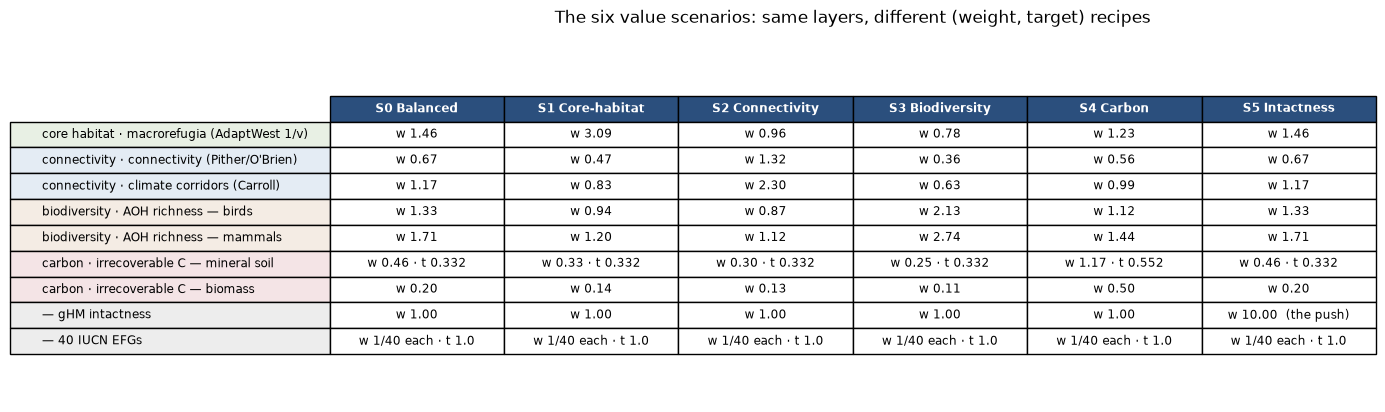

In [66]:
# ---- the six scenarios as one table --------------------------------------------------------
sc = json.loads((SPEC / "scenarios_v2.json").read_text())
order = [("core habitat", "climate_type_macrorefugia", "macrorefugia (AdaptWest 1/v)"),
         ("connectivity", "transboundary_connectivity", "connectivity (Pither/O'Brien)"),
         ("connectivity", "climate_corridors", "climate corridors (Carroll)"),
         ("biodiversity", "aoh_richness_birds", "AOH richness — birds"),
         ("biodiversity", "aoh_richness_mammals", "AOH richness — mammals"),
         ("carbon", "irrecoverable_carbon_m_soc", "irrecoverable C — mineral soil"),
         ("carbon", "irrecoverable_carbon_biomass", "irrecoverable C — biomass")]
scens = [("S0", "S0_balanced", "Balanced"), ("S1", "S1_core_habitat", "Core-habitat"),
         ("S2", "S2_connectivity", "Connectivity"), ("S3", "S3_biodiversity", "Biodiversity"),
         ("S4", "S4_carbon", "Carbon"), ("S5", None, "Intactness")]

def fmt(w, t):
    return f"w {w:.2f}" + (f" · t {t:.3f}" if t is not None else "")

tbl = {}
for sid, key, _ in scens:
    src = sc[key] if key else sc["S0_balanced"]          # S5 = S0 weights + the gHM push
    w, t = src["weights"], src["targets"]
    col = {}
    for blk, f, label in order:
        col[f"{blk} · {label}"] = fmt(w[f], t.get(f))
    col["— gHM intactness"] = "w 10.00  (the push)" if sid == "S5" else "w 1.00"
    col["— 40 IUCN EFGs"] = "w 1/40 each · t 1.0"
    tbl[f"{sid} {dict((a, c) for a, _, c in scens)[sid]}"] = col
T = pd.DataFrame(tbl)
print(T.to_string())
print("\nHandling, disclosed: gHM intactness is R3-INEXPRESSIBLE (leverage 0.042 -- no weight"
      "\ncan move it; S5's x10 push is the measured demonstration) and stays OUTSIDE the block"
      "\nbudgeting at w=1. The 40 EFGs are the locked adequacy FOUNDATION -- identical in every"
      "\nscenario, never a bargaining chip. Targets: m_soc 0.332 everywhere except S4's 0.552"
      "\n(theta 5x -> 3x); all other layers t = 1.0 (no satiation point).")

fig, ax = plt.subplots(figsize=(13.5, 4.6))
ax.axis("off")
mt = ax.table(cellText=T.values, rowLabels=T.index, colLabels=T.columns,
              cellLoc="center", loc="center")
mt.auto_set_font_size(False); mt.set_fontsize(8.3); mt.scale(1, 1.55)
for j in range(len(T.columns)):
    mt[0, j].set_facecolor("#2b4f7d"); mt[0, j].set_text_props(color="white", fontweight="bold")
for i, rl in enumerate(T.index, 1):
    blk = rl.split(" · ")[0]
    mt[i, -1].set_facecolor({"core habitat": "#e8f0e4", "connectivity": "#e4ecf4",
                             "biodiversity": "#f4ece4", "carbon": "#f4e4e6"}.get(blk, "#ededed"))
ax.set_title("The six value scenarios: same layers, different (weight, target) recipes",
             fontsize=12, pad=18)
fig.savefig(FIG / "gate4_scenario_table.png", dpi=200, bbox_inches="tight")
plt.show()

### How to read w and t — and why *leverage* decides which is which

- **w (weight)** — how hard a plan pursues a value, per unit still missing. Only *ratios*
  between weights matter (the math is scale-invariant); we print them scaled to average 1.
- **t (target)** — a *stopping point*: the captured fraction at which a value's claim is
  satisfied and it stops competing for land. `t = 1.0` is deliberately unreachable — it means
  "never satisfied, keep pushing" — so those values are steered by weight alone. A *reachable*
  target is a policy statement: m_soc's `t 0.332` reads "secure a third of the stock, then
  release the budget."
- **leverage** — the measured range a value's capture can possibly span across ALL feasible
  30% plans (its richest-30%-of-cells share minus its poorest). Leverage bounds what any
  weight can do: intactness at 0.04 means every plan captures ~30% *no matter what* — which is
  why S5's ×10 push moves nothing (measured, not assumed). Mammals' big weights compensate its
  small leverage (0.18) so its *influence* (w × achievable swing) matches its block share.
- **The rule connecting them** (frozen before any scenario ran): values whose mass
  *concentrates* enough to make a securable claim get a **target**; diffuse values get
  **weights**. The next figure is the measurement that applied that rule — only mineral-soil
  carbon qualifies.

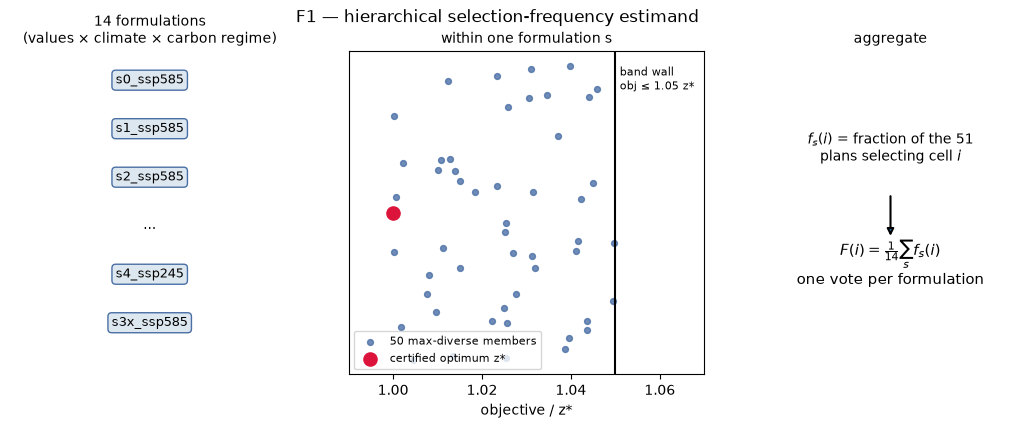

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.1, 1.4, 1]})
ax = axes[0]; ax.axis("off")
ax.set_title("14 formulations\n(values × climate × carbon regime)", fontsize=10)
show = ["s0_ssp585", "s1_ssp585", "s2_ssp585", "…", "s4_ssp245", "s3x_ssp585"]
for i, s in enumerate(show):
    ax.text(0.5, 0.9 - i * 0.15, s, ha="center", fontsize=9,
            bbox=None if s == "…" else dict(boxstyle="round", fc="#dde7f0", ec="#4a6fa5"))
ax = axes[1]
ax.set_title("within one formulation s", fontsize=10)
rng = np.random.default_rng(7)
zs = 1 + 0.05 * rng.random(50)
ax.scatter(zs, rng.random(50), s=18, c="#4a6fa5", alpha=0.8,
           label="50 max-diverse members")
ax.scatter([1.0], [0.5], s=90, c="crimson", zorder=5, label="certified optimum z*")
ax.axvline(1.05, color="black", lw=1.5)
ax.text(1.051, 0.98, "band wall\nobj ≤ 1.05 z*", fontsize=8, va="top")
ax.set_xlim(0.99, 1.07); ax.set_yticks([]); ax.set_xlabel("objective / z*")
ax.legend(fontsize=8, loc="lower left")
ax = axes[2]; ax.axis("off")
ax.set_title("aggregate", fontsize=10)
ax.text(0.5, 0.66, r"$f_s(i)$ = fraction of the 51" "\nplans selecting cell $i$",
        ha="center", fontsize=10)
ax.annotate("", xy=(0.5, 0.42), xytext=(0.5, 0.56),
            arrowprops=dict(arrowstyle="-|>", lw=1.5))
ax.text(0.5, 0.28, r"$F(i) = \frac{1}{14}\sum_s f_s(i)$" "\none vote per formulation",
        ha="center", fontsize=11)
fig.suptitle("F1 — hierarchical selection-frequency estimand", fontsize=12)
fig.savefig(FIG / "gate4_F1_schematic.png", dpi=200, bbox_inches="tight")
plt.show()

## The evidence behind the carbon treatment — the Gate-0a audit figure (F8)

The exact figure the decision was made from: marginal density ÷ regional mean as land is
added richest-first, every feature, log-x, with each θ = 5× crossing marked and labeled with
its area share. **Mineral-soil carbon is the outlier** — above 5× across the first **4.06%**
of the region, a sliver holding **33.2%** of the stock → the pre-registered rules assign it a
*target* (0.332). Biomass's tail is too small to qualify (1.17% / 6.6% → weight-governed);
nothing else comes close. This is why carbon-forward later turns out to be the one value
position with teeth.

wrote /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/analyses/y2y/figures/gate4_value_curves.png


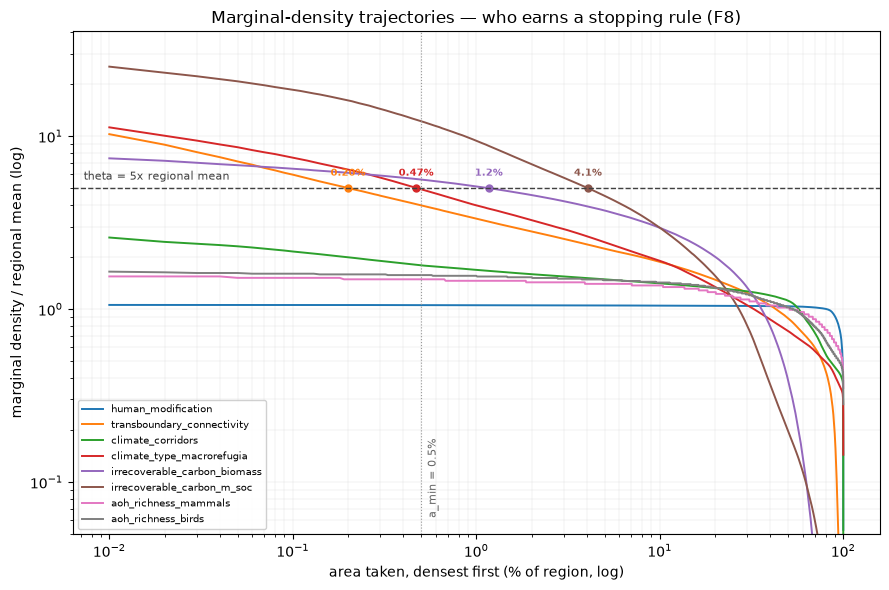

In [68]:
# ---- F8: the frozen-audit trajectory figure (leverage_core machinery, as reviewed) ---------
shortmap = {c: c.replace("irrecoverable_carbon_", "").replace("climate_type_", "")
                 .replace("aoh_richness_", "").replace("transboundary_", "")
                 .replace("human_modification", "intactness")
                 .replace("climate_corridors", "corridors")
            for c in lc.continuous_features()}          # (used by the star plots below)
fig = lc.trajectory_figure(fig_path=FIG / "gate4_value_curves.png")
plt.show()

## DECISION 1 — ratify the non-negotiables (frequent tier: F ≥ 0.70)

**6,816 km²** is selected by ≥70% of all 714 plans spanning every value position and both
climate futures — there is no defensible weighting of the group's own values under which this
land is unwanted. Clustered and profiled with the developed 04 machinery: star plots in all three
metrics (relative richness; % contribution to Y2Y totals; value density on the
shared scale) plus the native-unit raw table (tonnes of carbon, species counts,
amperes, EFG groups present). Proposed discussion move: *does anyone object to treating
these as consensus priorities?*

F >= 0.70 (ensemble): 6,816 km2 -> 44 clusters >= 25 km2
  Option  1:    508 km2 | mean F 0.77
  Option  2:    409 km2 | mean F 0.89
  Option  3:    251 km2 | mean F 0.86
  Option  4:    251 km2 | mean F 0.83
  Option  5:    229 km2 | mean F 0.79
  Option  6:    185 km2 | mean F 0.88


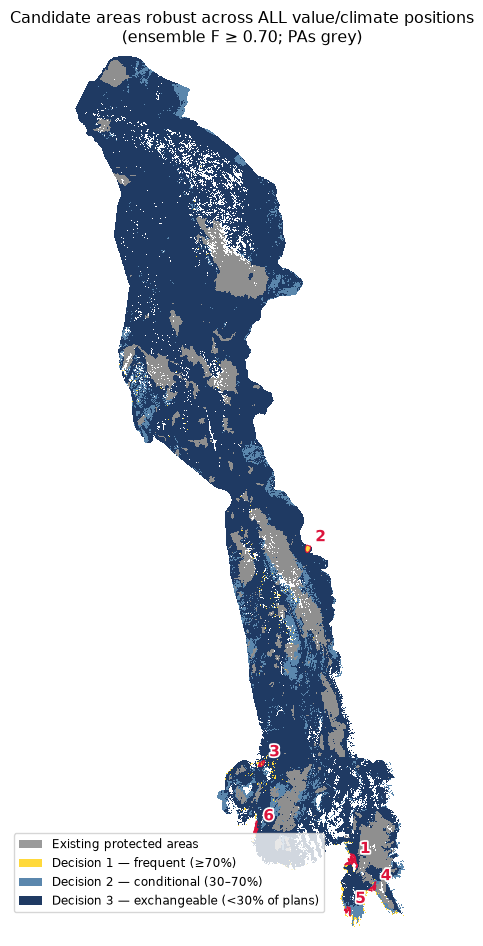

In [69]:
core = np.nan_to_num(to_grid(np.where(disc, Fh, np.nan)), nan=0.0) >= 0.70
lab, n = ndimage.label(core, structure=np.ones((3, 3)))
sizes = ndimage.sum(core, lab, index=np.arange(1, n + 1))
order = [i for i in (np.argsort(sizes)[::-1] + 1) if sizes[i - 1] >= config.CLUSTER_MIN_CELLS]
print(f"F >= 0.70 (ensemble): {int(core.sum()):,} km2 -> {len(order)} clusters >= "
      f"{config.CLUSTER_MIN_CELLS} km2")
OPT = {}
for rank, i in enumerate(order[:config.CLUSTER_MAX_PLOTS], 1):
    m = lab == i
    OPT[rank] = m
    print(f"  Option {rank:>2}: {int(sizes[i-1]):>6,} km2 | mean F "
          f"{float(np.nanmean(to_grid(Fh)[m])):.2f}")

PAg = np.full(pu.shape, np.nan, dtype=np.float32)
PAg[locked2d] = 1.0
fig, ax = plt.subplots(figsize=(7.5, 11.5))
# three solid decision brackets: exchangeable (<0.30) / conditional (0.30-0.70) / frequent (>=0.70)
BR_BOUNDS = [-0.001, 0.30, 0.70, 1.0]
BR_COLORS = ["#1f3a63", "#5b87ad", "#ffd93b"]
BR_NAMES = ["Decision 3 — exchangeable (<30% of plans)",
            "Decision 2 — conditional (30–70%)",
            "Decision 1 — frequent (≥70%)"]
im = ax.imshow(to_grid(np.where(disc, Fh, np.nan)), cmap=ListedColormap(BR_COLORS),
               norm=BoundaryNorm(BR_BOUNDS, 3), interpolation="nearest")
ax.imshow(PAg, cmap=ListedColormap(["#8f8f8f"]), interpolation="nearest")
for rank, m in OPT.items():
    ax.contour(m, levels=[0.5], colors="crimson", linewidths=0.7)
    cy, cx = ndimage.center_of_mass(m)
    ax.annotate(str(rank), xy=(cx, cy), xytext=(cx + 28, cy - 28), fontsize=11,
                fontweight="bold", color="crimson", path_effects=halo,
                arrowprops=dict(arrowstyle="-", color="crimson", lw=0.6))
ax.axis("off")
ax.set_title("Candidate areas robust across ALL value/climate positions\n"
             "(ensemble F ≥ 0.70; PAs grey)", fontsize=11.5)
handles = [Patch(facecolor="#9a9a9a", label="Existing protected areas")]
handles += [Patch(facecolor=c_, label=n_) for c_, n_ in zip(BR_COLORS[::-1], BR_NAMES[::-1])]
ax.legend(handles=handles, loc="lower left", bbox_to_anchor=(-0.18, 0.02),
          fontsize=8.5, frameon=True)
fig.savefig(FIG / "gate4_options_ensemble.png", dpi=200, bbox_inches="tight")
plt.show()

analysis=y2y | run=iter9_y2y_s0_pool | objective=min_shortfall | binary portfolio
region=Y2Y | figures -> output_data/iter9_y2y_s0_pool/figures
portfolio: 50 solution(s) | grid 1286 x 3312
  spread: 6 clusters over lat 45.9-66.8N
new candidate areas   : 7873 components, 6 kept (>= 25 cells, spread)
benchmark areas       : 6 profiled [named_pa]
cell size 1.0 km^2 | full-Y2Y PU denom = 1,272,914
shared efficiency scale EFF_RMAX = 0.30 %/1,000 km^2
  spread: 6 clusters over lat 42.3-53.4N
ensemble F>=0.70      : 1290 components, 6 kept (>= 25 cells, spread)


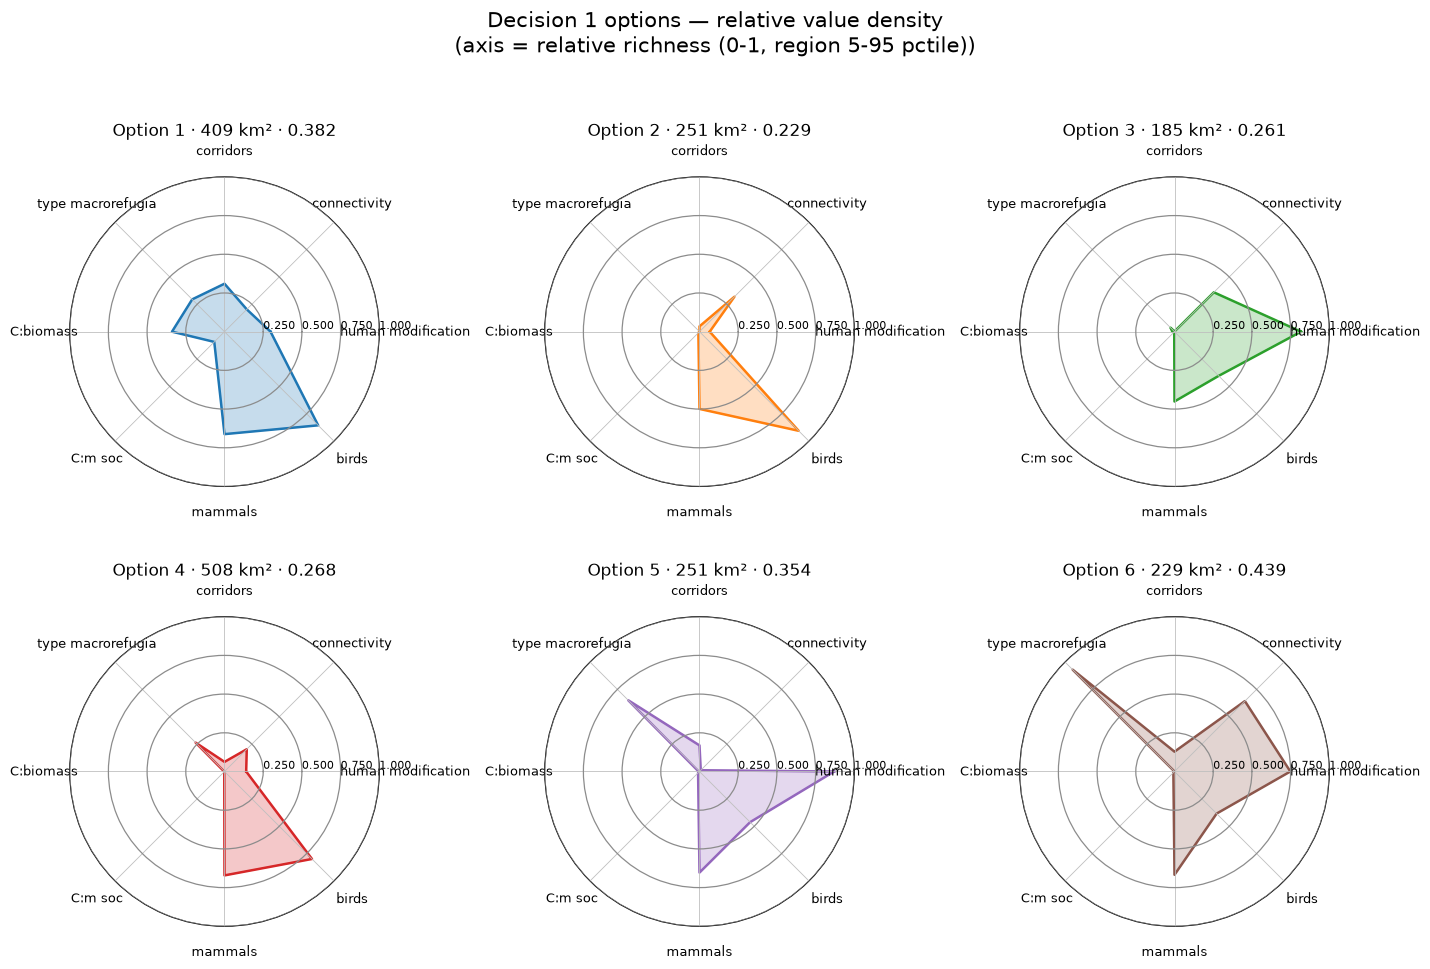


Decision-1 options -- native units:
                                                                           Option 1 Option 2 Option 3 Option 4 Option 5 Option 6
Intactness [intactness 0-1 (mean; 1-gHM)]                                     0.786    0.638    0.947    0.661    0.960    0.926
Connectivity [current density, amperes (mean)]                                 0.90     1.53     1.54     0.97     0.11     3.63
Climate corridors [current-flow centrality, amperes (mean)]                    4.98     3.06     2.76     3.26     4.00     3.72
Climate refugia [yr/km (mean; refugial residence = 1/backward velocity)]       0.41     0.13     0.18     0.38     0.72     0.97
Carbon: biomass [t C (total)]                                             1,087,813    2,322   19,846    9,429   10,930       36
Carbon: mineral soil [t C (total)]                                        1,048,691   70,203   12,462   30,930   89,555   64,513
Mammal richness [species/cell (mean)]                       

In [70]:
# ---- Decision-1 star plots via the DEVELOPED results_core standard -------------------------
# Same machinery as the OG 04 notebooks: mask_profile / plot_stars with the three metrics
# (relative richness, contribution to Y2Y totals, value density) and native-unit raw values.
# The carrier run (reference k-best) supplies the grid + stacks; the clusters come from the
# ENSEMBLE frequent band (F >= 0.70), so these are the Decision-1 Options.
import results_core as rc
importlib.reload(rc)
A = rc.load("y2y", run="iter9_y2y_s0_pool")
rc.load_rasters(A)
rc.build_stacks(A)
A.fig_dir = FIG

Fmask = np.nan_to_num(to_grid(np.where(disc, Fh, np.nan)), nan=0.0) >= 0.70
C_D1 = rc._cluster_profile(A, Fmask, "ensemble F>=0.70")
# density stars only, EFG axis OMITTED (a 40-layer block mean reads high everywhere
# and squashes the other spokes -- EFG stays in the raw table as "groups present")
import copy
A2 = copy.copy(A)
A2.axes_labels = A.axes_labels[:-1]
C_D1s = {**C_D1, "profs": {cid: C_D1["profs"][cid][:-1] for cid in C_D1["ids"]}}
rc.plot_stars(A2, C_D1s, "richness",
              "Decision 1 options — relative value density", "gate4_stars_richness.png")

# native-unit raw table (RAW_SPEC names/units/decimals -- the consequences-table convention)
rows = {}
for cid in C_D1["ids"]:
    rows[C_D1["names"][cid]] = C_D1["raw"][cid]
idx = [f"{rc.RAW_SPEC[n][0]} [{rc.RAW_SPEC[n][1]}]" for n in A.cont] + \
      ["Ecosystem groups (EFG) [groups present]"]
RAW_num = pd.DataFrame(rows, index=idx)
dps = [rc.RAW_SPEC[n][3] for n in A.cont] + [0]
RAW = pd.DataFrame({c: [f"{RAW_num[c].iloc[i]:,.{dps[i]}f}" for i in range(len(idx))]
                    for c in RAW_num.columns}, index=idx)
print("\nDecision-1 options -- native units:")
print(RAW.to_string())

## DECISION 2 — the values conversation, only where it matters (conditional tier)

**~93,000 km²** sits at F 0.30–0.70: land whose fate depends on which value position you
hold. The capture-delta table and price-of-pluralism table above set the stakes (*outcomes
barely move*); the panel below shows the **place** consequences: each forward scenario (high-
emissions layer; S0 shown in Decision 1), its near-optimal frequency in the decision brackets, its gains/losses against balanced, and **the two strongest coherent areas that
position would nominate** (numbered continuously, profiled in the stars below — note S5
nominates NOTHING: the inexpressible position cannot commit to places) — how the decision would differ,
position by position. Note S2: the connectivity-forward panel pins down the least land
(diffuse values widen the near-optimal set — a finding, not a failure; specific corridors
are the routing analysis's job).

anchor captures:
                   intactness  connectivity  corridors  macrorefugia  biomass  m_soc  mammals  birds
s0_ssp585_theta5        0.299         0.334      0.260         0.452    0.310  0.332    0.327  0.330
s1_ssp585_theta5        0.301         0.306      0.266         0.486    0.283  0.332    0.321  0.321
s2_ssp585_theta5        0.302         0.388      0.282         0.420    0.300  0.332    0.315  0.314
s3_ssp585_theta5        0.296         0.317      0.243         0.407    0.293  0.332    0.338  0.344
s4_ssp585_theta3        0.302         0.321      0.284         0.418    0.329  0.552    0.310  0.308
s5_ssp585_theta5        0.306         0.346      0.268         0.457    0.324  0.332    0.326  0.326
s0_ssp245_theta5        0.299         0.332      0.255         0.428    0.306  0.332    0.330  0.333
s1_ssp245_theta5        0.301         0.308      0.258         0.456    0.288  0.332    0.327  0.327
s2_ssp245_theta5        0.302         0.388      0.278         0.401    0.

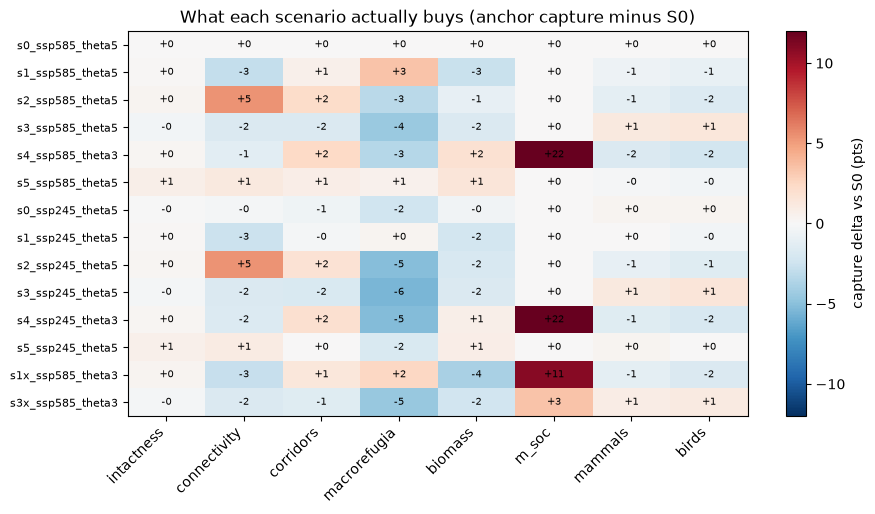


CORRIDORS-FORWARD vs S0: corridors capture 0.260 -> 0.282 (+2.2 pts); connectivity 0.334 -> 0.388; anchor Jaccard vs S0 = 0.763; cells with |delta f| > 0.2: 5,814
Reading: doubling the connectivity block moves the corridors OUTCOME only a few points
(leverage bounds it) but relocates substantial MAP area toward corridor-dense cells --
the scenario's benefit is WHERE it protects, which the delta-f map below shows.


In [71]:
T1 = pd.read_csv(SPEC / "T1_anchor_captures.csv", index_col=0)
short = {c: c.replace("irrecoverable_carbon_", "").replace("climate_type_", "")
             .replace("aoh_richness_", "").replace("transboundary_", "")
             .replace("human_modification", "intactness").replace("climate_corridors", "corridors")
         for c in T1.columns}
T1s = T1.rename(columns=short)
print("anchor captures:")
print(T1s.round(3).to_string())
delta = (T1s - T1s.loc["s0_ssp585_theta5"]) * 100
print("\ndelta vs S0 (percentage points):")
print(delta.round(1).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(delta.values, cmap="RdBu_r", vmin=-12, vmax=12, aspect="auto")
ax.set_xticks(range(len(delta.columns))); ax.set_xticklabels(delta.columns, rotation=45, ha="right")
ax.set_yticks(range(len(delta.index))); ax.set_yticklabels(delta.index, fontsize=8)
for i in range(delta.shape[0]):
    for j in range(delta.shape[1]):
        ax.text(j, i, f"{delta.values[i, j]:+.0f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, label="capture delta vs S0 (pts)")
ax.set_title("What each scenario actually buys (anchor capture minus S0)")
fig.savefig(FIG / "gate4_capture_deltas.png", dpi=200, bbox_inches="tight")
plt.show()

# THE CORRIDORS QUESTION: did corridors-forward (S2) buy distinct corridor benefit?
s2, s0 = "s2_ssp585_theta5", "s0_ssp585_theta5"
dcap = (T1s.loc[s2, "corridors"] - T1s.loc[s0, "corridors"]) * 100
jac = float((ANCHORS[s2] & ANCHORS[s0]).sum() / (ANCHORS[s2] | ANCHORS[s0]).sum())
df_map = F_FORM[s2] - F_FORM[s0]
moved = int((np.abs(df_map) > 0.2).sum())
print(f"\nCORRIDORS-FORWARD vs S0: corridors capture {T1s.loc[s0,'corridors']:.3f} -> "
      f"{T1s.loc[s2,'corridors']:.3f} ({dcap:+.1f} pts); connectivity "
      f"{T1s.loc[s0,'connectivity']:.3f} -> {T1s.loc[s2,'connectivity']:.3f}; "
      f"anchor Jaccard vs S0 = {jac:.3f}; cells with |delta f| > 0.2: {moved:,}")
print("Reading: doubling the connectivity block moves the corridors OUTCOME only a few points"
      "\n(leverage bounds it) but relocates substantial MAP area toward corridor-dense cells --"
      "\nthe scenario's benefit is WHERE it protects, which the delta-f map below shows.")

### The price of pluralism — zero-solve answer to "is everything canceling out?"

Each value's best achieved capture across all 14 formulations, against its **solo ceiling**
(cap_max from the frozen audit: what a 30% budget could capture pursuing that value alone).
Balancing eight-plus values costs most of them only 10–30% of their single-minded maximum —
because the ceilings themselves are structural (leverage), not artifacts of sharing. The two
genuine prices: the connectivity pair (~30% below ceiling — the family that gains most from
its own scenario) and biomass (deliberately demoted to co-benefit; its ceiling was the a0
dominance problem).

In [72]:
# ---- price of pluralism: best achieved capture vs solo ceiling (zero solves) ---------------
T2f = pd.read_csv(ROOT / "analyses/y2y/audit/audit_objects/feature_characterization.csv"
                  ).set_index("feature")
best = T1s.max(axis=0)
rows = []
for feat in T2f.index:
    nm = short[feat]
    ceil = float(T2f.loc[feat, "cap_max"])
    ach = float(best[nm])
    rows.append(dict(value=nm, solo_ceiling=round(ceil, 3), best_achieved=round(ach, 3),
                     pct_of_ceiling=round(100 * ach / ceil, 0),
                     price_of_pluralism=f"{100 * (1 - ach / ceil):.0f}%"))
PP = pd.DataFrame(rows).set_index("value")
print(PP.to_string())
print("\nnotes: m_soc's 'achieved' is its S4 target (0.552) -- capped by CHOICE, not by "
      "competition;\nbiomass is deliberately demoted (its ceiling is the a0 dominance "
      "problem); macrorefugia's\nceiling is the canonical-585 figure (the 245 layer's is "
      "higher, 0.599).")

              solo_ceiling  best_achieved  pct_of_ceiling price_of_pluralism
value                                                                       
intactness           0.314          0.306            97.0                 3%
connectivity         0.552          0.388            70.0                30%
corridors            0.419          0.284            68.0                32%
macrorefugia         0.558          0.486            87.0                13%
biomass              0.803          0.329            41.0                59%
m_soc                0.889          0.552            62.0                38%
mammals              0.390          0.339            87.0                13%
birds                0.413          0.344            83.0                17%

notes: m_soc's 'achieved' is its S4 target (0.552) -- capped by CHOICE, not by competition;
biomass is deliberately demoted (its ceiling is the a0 dominance problem); macrorefugia's
ceiling is the canonical-585 figure (the 245 la

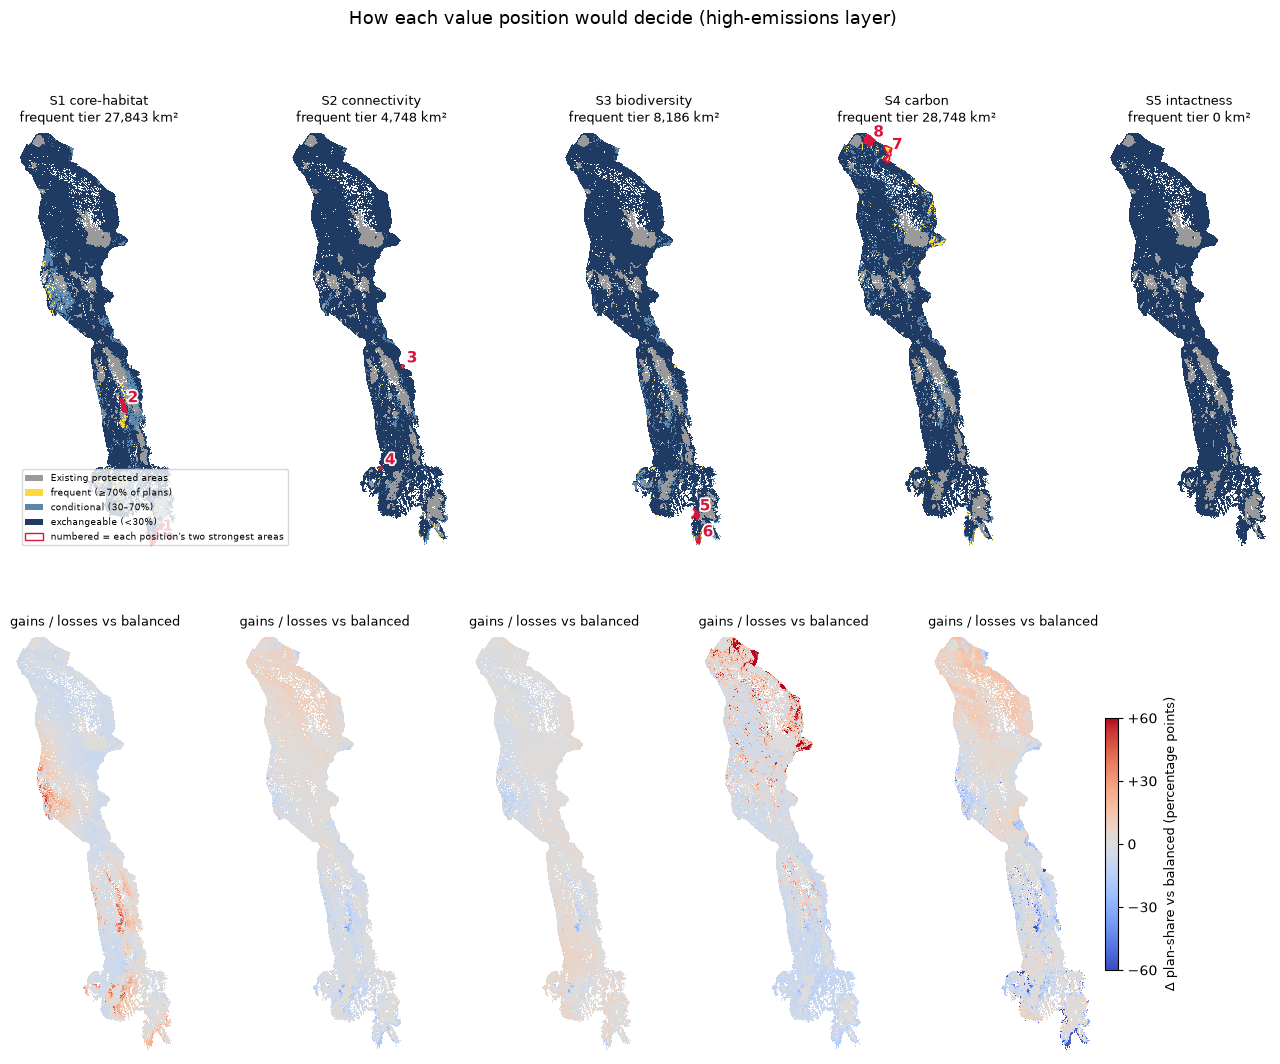

{1: 'S1 core-habitat · 4,417 km2', 2: 'S1 core-habitat · 1,763 km2', 3: 'S2 connectivity · 409 km2', 4: 'S2 connectivity · 251 km2', 5: 'S3 biodiversity · 880 km2', 6: 'S3 biodiversity · 675 km2', 7: 'S4 carbon · 4,298 km2', 8: 'S4 carbon · 2,818 km2'}


In [73]:
# ---- five forward scenarios: bracketed f + continuously-numbered picks + gains/losses ------
BRB = [-0.001, 0.30, 0.70, 1.0]
BRC = ["#1f3a63", "#5b87ad", "#ffd93b"]
PAg = np.full(pu.shape, np.nan, dtype=np.float32)
PAg[locked2d] = 1.0
f0 = F_FORM["s0_ssp585_theta5"]
SC5 = [("s1_ssp585_theta5", "S1 core-habitat"), ("s2_ssp585_theta5", "S2 connectivity"),
       ("s3_ssp585_theta5", "S3 biodiversity"), ("s4_ssp585_theta3", "S4 carbon"),
       ("s5_ssp585_theta5", "S5 intactness")]

D2OPT = {}                      # continuous number -> dict(mask, scenario, cells)
knum = 0
fig, axes = plt.subplots(2, 5, figsize=(17, 12))
for j, (c, title) in enumerate(SC5):
    fgrid = to_grid(np.where(disc, F_FORM[c], np.nan))
    ax = axes[0, j]
    ax.imshow(fgrid[::2, ::2], cmap=ListedColormap(BRC), norm=BoundaryNorm(BRB, 3),
              interpolation="nearest")
    ax.imshow(PAg[::2, ::2], cmap=ListedColormap(["#9a9a9a"]), interpolation="nearest")
    m70 = np.nan_to_num(fgrid, nan=0.0) >= 0.70
    lab, n = ndimage.label(m70, structure=np.ones((3, 3)))
    if n:
        wgt = ndimage.sum(np.nan_to_num(fgrid, nan=0.0), lab, index=np.arange(1, n + 1))
        cnt = ndimage.sum(m70, lab, index=np.arange(1, n + 1))
        ranked = [i for i in (np.argsort(wgt)[::-1] + 1)
                  if cnt[i - 1] >= config.CLUSTER_MIN_CELLS][:2]
        for i in ranked:
            knum += 1
            D2OPT[knum] = dict(mask=(lab == i), scenario=title, cells=int(cnt[i - 1]))
            mm = (lab == i)[::2, ::2]
            ax.contour(mm, levels=[0.5], colors="crimson", linewidths=1.0)
            cy, cx = ndimage.center_of_mass(mm)
            ax.annotate(str(knum), xy=(cx, cy), xytext=(cx + 16, cy - 16), fontsize=11,
                        fontweight="bold", color="crimson", path_effects=halo,
                        arrowprops=dict(arrowstyle="-", color="crimson", lw=0.6))
    freq_km2 = int((F_FORM[c][disc] >= 0.70).sum())
    ax.axis("off")
    ax.set_title(f"{title}\nfrequent tier {freq_km2:,} km²", fontsize=9.5)
    ax = axes[1, j]
    im = ax.imshow(to_grid(F_FORM[c] - f0)[::2, ::2], cmap="coolwarm", vmin=-0.6, vmax=0.6,
                   interpolation="nearest")
    ax.axis("off")
    ax.set_title("gains / losses vs balanced", fontsize=9)
handles = [Patch(facecolor="#9a9a9a", label="Existing protected areas"),
           Patch(facecolor="#ffd93b", label="frequent (≥70% of plans)"),
           Patch(facecolor="#5b87ad", label="conditional (30–70%)"),
           Patch(facecolor="#1f3a63", label="exchangeable (<30%)"),
           Patch(facecolor="none", edgecolor="crimson",
                 label="numbered = each position's two strongest areas")]
axes[0, 0].legend(handles=handles, loc="lower left", fontsize=6.5, frameon=True)
cb = fig.colorbar(im, ax=axes[1, :], shrink=0.6, pad=0.008)
cb.set_ticks([-0.6, -0.3, 0, 0.3, 0.6]); cb.set_ticklabels(["−60", "−30", "0", "+30", "+60"])
cb.set_label("Δ plan-share vs balanced (percentage points)", fontsize=9)
fig.suptitle("How each value position would decide (high-emissions layer)", fontsize=13, y=0.98)
fig.savefig(FIG / "gate4_scenario_decisions.png", dpi=170, bbox_inches="tight")
plt.show()
print({k: f"{v['scenario']} · {v['cells']:,} km2" for k, v in D2OPT.items()})

### The nominated areas, profiled

Star plots for the nominated Options (continuous numbering from the panel above), same developed
density standard as Decision 1 (region 5–95 pctile scaling, EFG axis omitted — EFG counts in
the titles' source scenarios' raw tables).

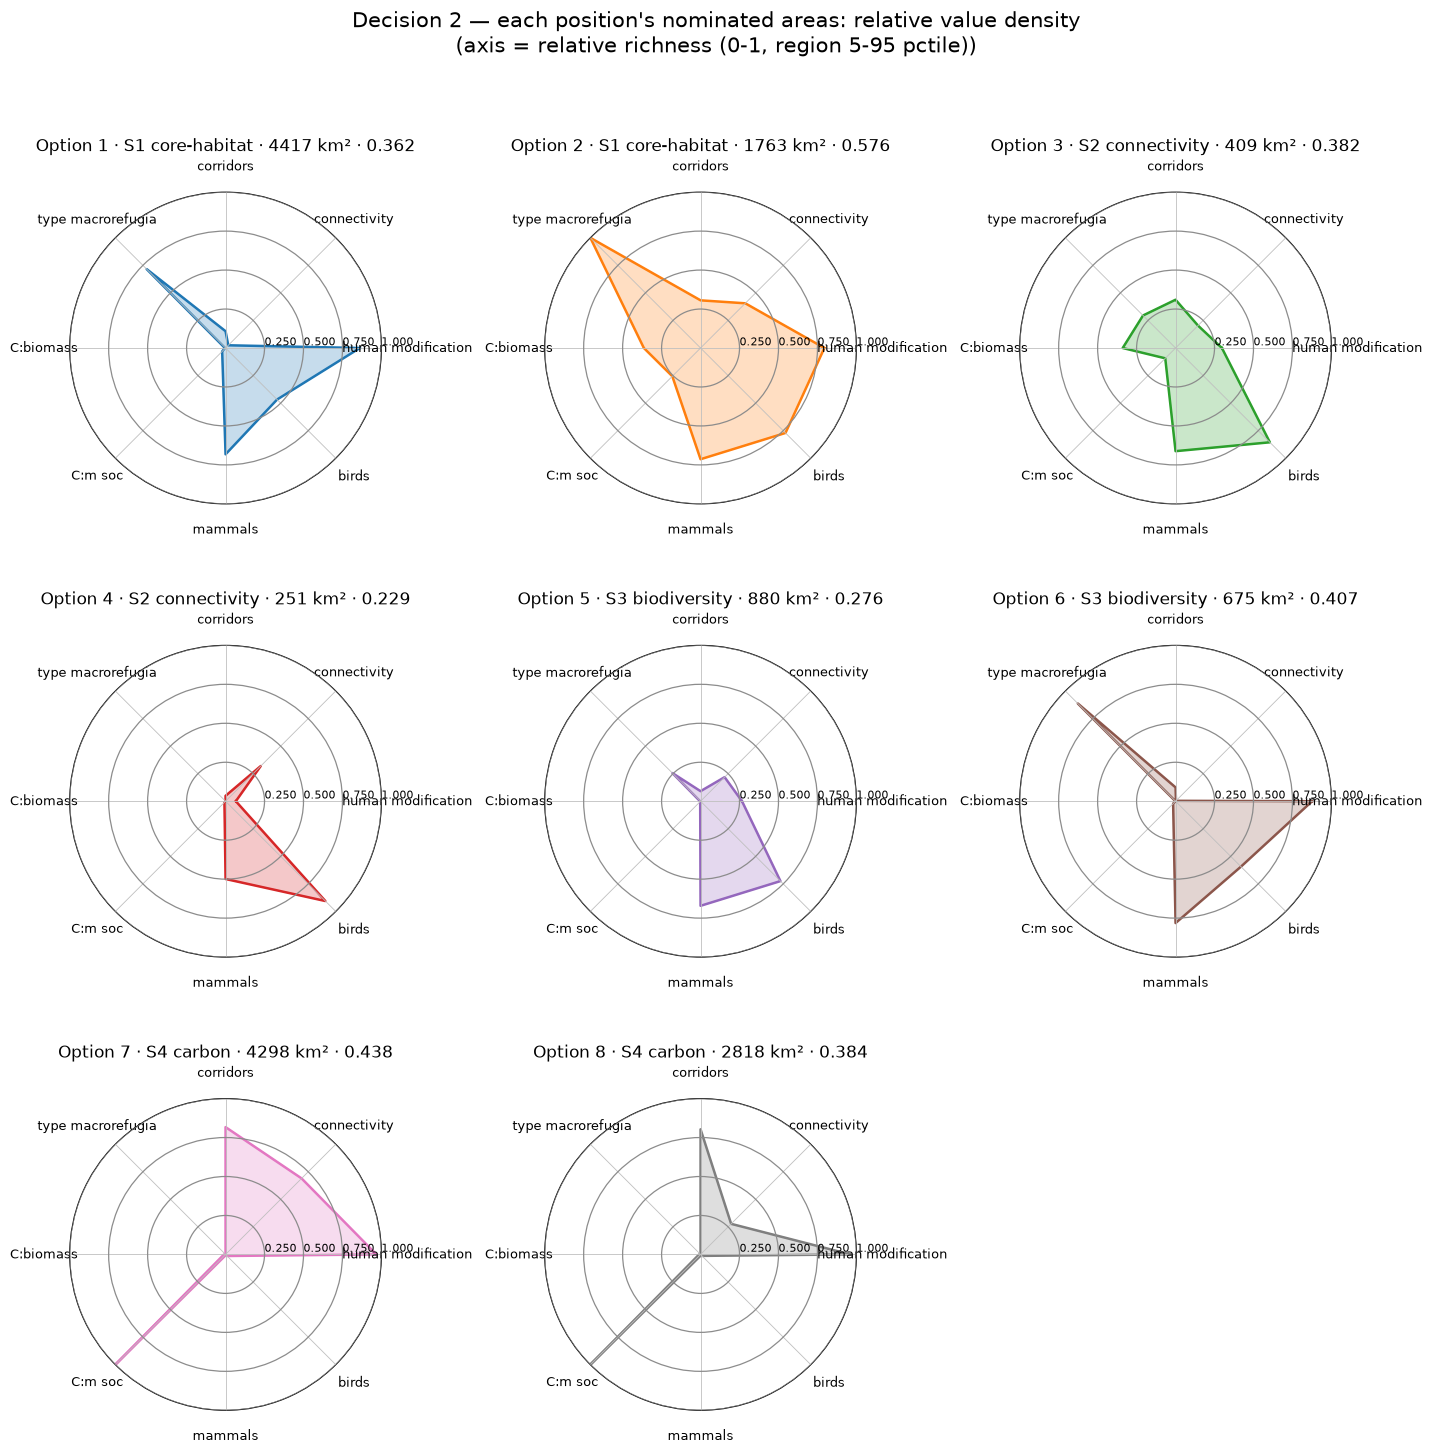

In [74]:
# ---- density stars for the 10 Decision-2 picks (reuses the results_core carrier A) ---------
CLUSTER_CMAP_ = plt.get_cmap("tab10")
C_D2 = dict(ids=list(D2OPT), colors={k: CLUSTER_CMAP_((k - 1) % 10) for k in D2OPT},
            names={k: f"Option {k} · {D2OPT[k]['scenario']}" for k in D2OPT},
            cnt={k: D2OPT[k]["cells"] for k in D2OPT},
            profs={}, contrib={}, eff={}, raw={})
for k, d in D2OPT.items():
    prof, contrib, eff, raw = rc.mask_profile(A, d["mask"])
    C_D2["profs"][k] = prof[:-1]              # EFG axis omitted, as in Decision 1
    C_D2["contrib"][k], C_D2["eff"][k], C_D2["raw"][k] = contrib, eff, raw
rc.plot_stars(A2, C_D2, "richness",
              "Decision 2 — each position's nominated areas: relative value density",
              "gate4_d2_stars.png")

## DECISION 3 — allocate the freedom deliberately (rare tier)

**~950,000 km²** is exchangeable: within 5% of optimal, plans swap this land freely, and 156
of 182 formulation pairs sit inside each other's tolerance (E11). Formal license for the
group: **criteria outside the model — Indigenous leadership, availability, cost, partnership,
the corridor analysis's linkages — may govern selection across most of the landscape at
almost no cost in modeled value.** The banded map shows the tiers together; the north is
where this freedom (and therefore those criteria) matter most.

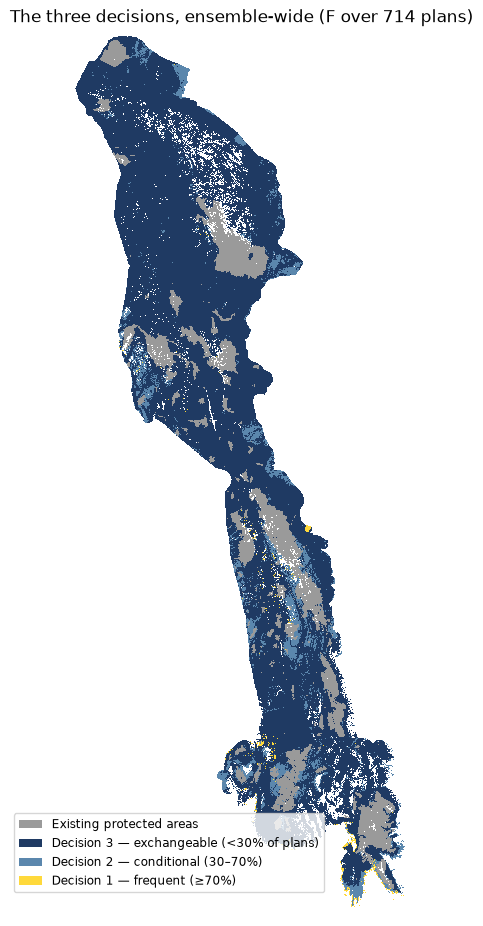

  Decision 3 — exchangeable (<30% of plans)   981,661 km2
  Decision 2 — conditional (30–70%)    93,408 km2
  Decision 1 — frequent (≥70%)     6,816 km2

E11: 156/182 formulation pairs mutually within 5% bands; anchor Jaccard 0.37-0.93


In [75]:
bounds = [-0.001, 0.30, 0.70, 1.0]
names = ["Decision 3 — exchangeable (<30% of plans)",
         "Decision 2 — conditional (30–70%)",
         "Decision 1 — frequent (≥70%)"]
colors = ["#1f3a63", "#5b87ad", "#ffd93b"]
Fg = to_grid(np.where(disc, Fh, np.nan))
PAg = np.full(pu.shape, np.nan, dtype=np.float32); PAg[locked2d] = 1.0
fig, ax = plt.subplots(figsize=(7.5, 11.5))
ax.imshow(Fg, cmap=ListedColormap(colors), norm=BoundaryNorm(bounds, 3), interpolation="nearest")
ax.imshow(PAg, cmap=ListedColormap(["#9a9a9a"]), interpolation="nearest")
ax.axis("off")
ax.set_title("The three decisions, ensemble-wide (F over 714 plans)", fontsize=12)
handles = [Patch(facecolor="#9a9a9a", label="Existing protected areas")]
handles += [Patch(facecolor=c, label=n) for c, n in zip(colors, names)]
ax.legend(handles=handles, loc="lower left", bbox_to_anchor=(-0.18, 0.02), fontsize=8.5,
          frameon=True)
fig.savefig(FIG / "gate4_decisions_map.png", dpi=200, bbox_inches="tight")
plt.show()
fd = Fh[disc]
for lo, hi, nm in zip(bounds[:-1], bounds[1:], names):
    print(f"  {nm:<22} {int(((fd > lo) & (fd <= hi)).sum()):>9,} km2")
J = pd.read_csv(SPEC / "E11_anchor_jaccard.csv", index_col=0)
D = pd.read_csv(SPEC / "E11_delta_matrix.csv", index_col=0).values.astype(float)
print(f"\nE11: {int((D <= 0.05).sum()) - 14}/182 formulation pairs mutually within 5% bands; "
      f"anchor Jaccard {J.values[~np.eye(14, dtype=bool)].min():.2f}-"
      f"{J.values[~np.eye(14, dtype=bool)].max():.2f}")

## The exception — carbon's strongholds don't come free

The one value position other near-optimal plans genuinely fail (Δ 8.5–9.3%): carbon-forward.
Its demand traces straight back to the concentration curve above — a securable claim exists,
so the position claims it. The bars: balanced plans hold only ~43% of the dense-stand mass;
carbon-forward's target+weights secure ~96%/77%; a deep target WITHOUT the weights (crossed
formulations) under-delivers — **securing the strongholds is a choice, made with both levers,
or not at all.**

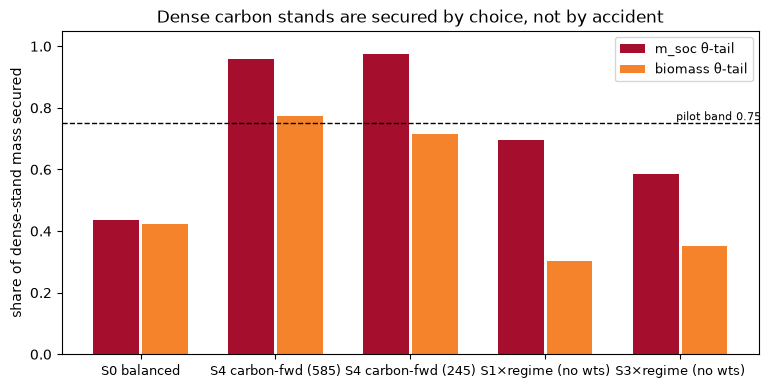

In [76]:
TT = pd.read_csv(SPEC / "T1_tail_capture.csv", index_col=0)
sel_rows = ["s0_ssp585_theta5", "s4_ssp585_theta3", "s4_ssp245_theta3",
            "s1x_ssp585_theta3", "s3x_ssp585_theta3"]
lbl = ["S0 balanced", "S4 carbon-fwd (585)", "S4 carbon-fwd (245)",
       "S1×regime (no wts)", "S3×regime (no wts)"]
sub = TT.loc[sel_rows, ["irrecoverable_carbon_m_soc", "irrecoverable_carbon_biomass"]]
x = np.arange(len(sub))
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(x - 0.18, sub.iloc[:, 0], width=0.34, color="#a50f2d", label="m_soc θ-tail")
ax.bar(x + 0.18, sub.iloc[:, 1], width=0.34, color="#f4832c", label="biomass θ-tail")
ax.axhline(0.75, color="black", ls="--", lw=1)
ax.text(len(sub) - 0.4, 0.76, "pilot band 0.75", fontsize=8, ha="right")
ax.set_xticks(x); ax.set_xticklabels(lbl, fontsize=9)
ax.set_ylabel("share of dense-stand mass secured")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.set_title("Dense carbon stands are secured by choice, not by accident")
fig.savefig(FIG / "gate4_carbon_exception.png", dpi=200, bbox_inches="tight")
plt.show()

## Caveats to state before someone else does

- **Silent ≠ worthless:** intactness is structurally inexpressible here (leverage 0.042; the
  ×10 push in S5 moved nothing), and new selections skew toward more-modified valley land via
  the richness–footprint correlation. Governance and cultural values aren't rasters at all.
- **This map is about additions**: the locked PA estate (grey) frames everything.
- **Estimator-conditional freedom**: frequencies come from maximally-diverse band members —
  stress-tested breadth, not sampling probability.
- **The cheap consensus:** the emissions scenario moves the frequency surface by 0.2% — don't
  spend meeting time on it.

*Gate 5 promotes the keepers to publication grade; E8–E10 supplementary arms → notebook 15.*